# Wall-Clock Intractability of Full-Horizon Adjustment

Reproduces the figure motivating Algorithm 1 (windowed sequential $\pi$-backdoor adjustment) in the appendix. Timing data is taken directly from `out_wallclock.ipynb`, which measures the wall-clock cost of computing per-timestep adjustment sets $\mathbf{Z}_t^k$ on the Confounded HumanoidMaze-Large causal diagram ($H=2000$) as a function of window size $k$. Setting $k = H$ recovers the exact (non-windowed) sequential $\pi$-backdoor computation used by Causal BC and Causal GAIL; smaller $k$ corresponds to the windowed approximation of Algorithm 1.

The underlying sweep took ~4.7 hours to run (dominated by the $k=2000$ point alone, at ~4.1 hours), so we hardcode the recorded runtimes here rather than recomputing them.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 16,
    "axes.titlesize": 17,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 150,
})

PLOTS_DIR = '/home/et2842/causal/causalrl/examples/experiments/plots/wallclock'
os.makedirs(PLOTS_DIR, exist_ok=True)

## Data (extracted from `out_wallclock.ipynb` output)

In [2]:
# HumanoidMaze-Large (H=2000), seed=0
# k=2000 corresponds to full-horizon (non-windowed) adjustment
lookback_k = np.array([1, 10, 50, 100, 200, 500, 1000, 2000])
runtime_s = np.array([
    7.080,
    7.105,
    7.640,
    9.986,
    24.528,
    255.817,
    1930.978,
    14853.568,
])

# Window sizes actually used by Causal SQIL / Causal IQ-Learn in the main
# experiments (Appendix: Hyperparameters and Training Details)
PRACTICAL_K_HUMANOID = 2
PRACTICAL_K_ANTMAZE = 10
FULL_HORIZON_K = 2000

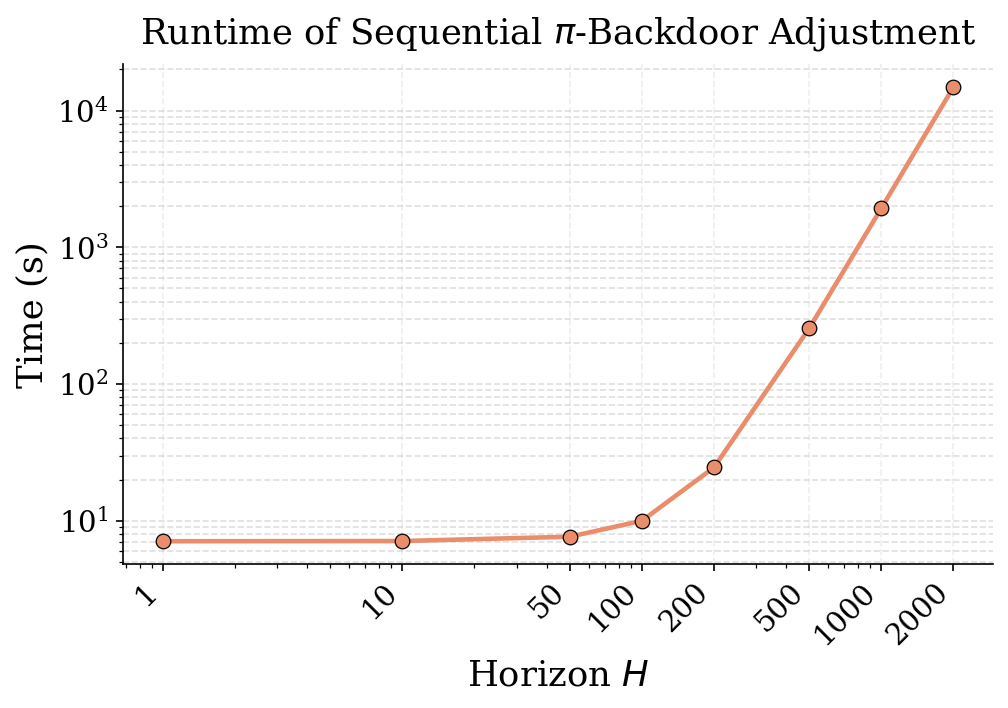

In [3]:
# Deep navy, consistent with the AntMaze causal-method palette used elsewhere
import seaborn as sns
C_LINE = sns.color_palette("flare")[0]

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    lookback_k, runtime_s, 'o-',
    color=C_LINE, linewidth=2.2, markersize=7,
    markeredgecolor='black', markeredgewidth=0.6, zorder=3,
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(lookback_k)
ax.set_xticklabels([str(k) for k in lookback_k], rotation=45, ha='right')
ax.set_xlabel('Horizon $H$')
ax.set_ylabel('Time (s)')
ax.set_title('Runtime of Sequential $\\pi$-Backdoor Adjustment', pad=10)

ax.yaxis.grid(True, which='both', linestyle='--', alpha=0.4)
ax.xaxis.grid(True, which='major', linestyle='--', alpha=0.2)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

fig.savefig(f'{PLOTS_DIR}/wallclock.pdf', dpi=300, bbox_inches='tight')
plt.show()